# In this notebook, we present the code used to train the model on the Stellar Spectra dataset

We import the necessary libraries. Note that we use the spectraltools library, from which we import the Spectral layer that can be used as a Keras layer.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import matplotlib 
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20)

from sklearn.model_selection import train_test_split
from spectraltools import Spectral
from tensorflow import keras
from tensorflow.keras.models import save_model #saveweights
from tensorflow.keras.models import load_model

The Dataset is loaded (a reduced version of the dataset used in the paper is provided here).

In [42]:
delimiter = ' '

# Load the file
df_spectrum = pd.read_csv('miles_stars.csv')

# Reset the index
df_spectrum.reset_index(drop=True, inplace=True)

wavelength = df_spectrum['wav'].astype(float)
star_id = 's0982'
star_spectrum = df_spectrum[star_id].astype(float)

file_path = 'params.ascii'
df_params = pd.read_csv(file_path, delimiter=' ')
df_params.set_index('ID', inplace=True)## Data Cleaning
df_params = df_params[-100:]
df_params.reset_index(inplace=True)

Data Cleaning

In [43]:
# Remove the first and the last part of the spectrum where the instrument does not return values of intensity
df_spectrum = df_spectrum.iloc[50:len(df_spectrum.iloc[:,0])-30, :]
wavelength = df_spectrum['wav'].astype(float)

star_spectrum = df_spectrum[star_id].astype(float)
df_spectrum = df_spectrum.astype(float)
df_spectrum = df_spectrum.iloc[:,:-1]

Normalization

In [44]:
# Normalize the columns
normalized_df =df_spectrum.div(df_spectrum.max())
df_spectrum = normalized_df

In [45]:
#remove nan and inf
nan_indices = df_params.index[df_params['__Fe_H_'].isna()]
inf_indices = df_params.index[np.isinf(df_params['__Fe_H_'])]
indices_to_drop = df_spectrum.T.index[nan_indices]
df_spectrum_metallicity = df_spectrum.T.drop(indices_to_drop).T
cleaned_data_metallicity = df_params['__Fe_H_'].replace([np.inf, -np.inf], np.nan).dropna()

max_metallicity = max(np.abs(cleaned_data_metallicity))
cleaned_data_metallicity = cleaned_data_metallicity / max_metallicity

df_spectrum_metallicity = df_spectrum_metallicity.T

X = df_spectrum_metallicity
y = cleaned_data_metallicity

In [46]:
X.shape

(97, 4287)

The Sequential class in tf.keras is used to build the model layer-by-layer. A Spectral layer is used as first layer.

In [47]:
# SPECTRAL NN MODEL

def spectral_model():
    mod = tf.keras.Sequential()
    mod.add(tf.keras.Input(shape=(x_train.shape[1])))
    mod.add(Spectral(units=200,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='relu',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones',
                     diag_regularizer=tf.keras.regularizers.L2(l2=1e-2),
                     base_regularizer=tf.keras.regularizers.L2(l2=1e-4)))
    mod.add(tf.keras.layers.BatchNormalization())
    mod.add(tf.keras.layers.Dropout(0.01))
    mod.add(Spectral(units=50,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='tanh',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
#     mod.add(tf.keras.layers.Dropout(0.1))
    mod.add(Spectral(units=50,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='tanh',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
#     mod.add(tf.keras.layers.Dropout(0.1))
    mod.add(Spectral(1,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='tanh',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
    return mod


The model is trained and the input eigenvalues are stored.

In [48]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [49]:

mod = spectral_model()
mod.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mae',
    metrics='mae',
)

hist = mod.fit(x_train, y_train,
               batch_size=10,
               epochs=1000,
               validation_split=0.1,
               verbose=1)

eig_start = Spectral.return_diag(mod.layers[0])
base_start = mod.layers[0].base
norma = tf.linalg.norm(base_start, ord=2, axis=1)
eig_norm = (eig_start * norma)
eig_norm = eig_norm.numpy()

Epoch 1/1000
7/7 [==============================] - 2s 60ms/step - loss: 43.1353 - mae: 0.4751 - val_loss: 42.5258 - val_mae: 0.2065
Epoch 2/1000
7/7 [==============================] - 0s 27ms/step - loss: 42.3141 - mae: 0.2445 - val_loss: 41.9870 - val_mae: 0.2583
Epoch 3/1000
7/7 [==============================] - 0s 28ms/step - loss: 41.6962 - mae: 0.2155 - val_loss: 41.3594 - val_mae: 0.2169
Epoch 4/1000
7/7 [==============================] - 0s 30ms/step - loss: 41.0867 - mae: 0.1899 - val_loss: 40.7860 - val_mae: 0.2241
Epoch 5/1000
7/7 [==============================] - 0s 29ms/step - loss: 40.5405 - mae: 0.2219 - val_loss: 40.3025 - val_mae: 0.3156
Epoch 6/1000
7/7 [==============================] - 0s 28ms/step - loss: 39.9711 - mae: 0.2252 - val_loss: 39.7608 - val_mae: 0.3433
Epoch 7/1000
7/7 [==============================] - 0s 29ms/step - loss: 39.3876 - mae: 0.2085 - val_loss: 39.3263 - val_mae: 0.4722
Epoch 8/1000
7/7 [==============================] - 0s 27ms/step - lo

7/7 [==============================] - 0s 26ms/step - loss: 16.3575 - mae: 0.1331 - val_loss: 16.1882 - val_mae: 0.1303
Epoch 63/1000
7/7 [==============================] - 0s 26ms/step - loss: 16.0865 - mae: 0.1493 - val_loss: 15.8885 - val_mae: 0.1154
Epoch 64/1000
7/7 [==============================] - 0s 32ms/step - loss: 15.7612 - mae: 0.1071 - val_loss: 15.5862 - val_mae: 0.0940
Epoch 65/1000
7/7 [==============================] - 0s 33ms/step - loss: 15.5047 - mae: 0.1298 - val_loss: 15.3159 - val_mae: 0.1007
Epoch 66/1000
7/7 [==============================] - 0s 26ms/step - loss: 15.2053 - mae: 0.1058 - val_loss: 15.0879 - val_mae: 0.1458
Epoch 67/1000
7/7 [==============================] - 0s 27ms/step - loss: 14.9475 - mae: 0.1195 - val_loss: 14.8862 - val_mae: 0.2134
Epoch 68/1000
7/7 [==============================] - 0s 27ms/step - loss: 14.7087 - mae: 0.1483 - val_loss: 14.5646 - val_mae: 0.1573
Epoch 69/1000
7/7 [==============================] - 0s 26ms/step - loss: 14

7/7 [==============================] - 0s 29ms/step - loss: 4.8174 - mae: 0.1071 - val_loss: 4.8700 - val_mae: 0.2220
Epoch 124/1000
7/7 [==============================] - 0s 25ms/step - loss: 4.7045 - mae: 0.1015 - val_loss: 4.6717 - val_mae: 0.1299
Epoch 125/1000
7/7 [==============================] - 0s 28ms/step - loss: 4.5806 - mae: 0.0829 - val_loss: 4.5434 - val_mae: 0.1058
Epoch 126/1000
7/7 [==============================] - 0s 27ms/step - loss: 4.5077 - mae: 0.1135 - val_loss: 4.4872 - val_mae: 0.1518
Epoch 127/1000
7/7 [==============================] - 0s 29ms/step - loss: 4.3675 - mae: 0.0747 - val_loss: 4.3554 - val_mae: 0.1203
Epoch 128/1000
7/7 [==============================] - 0s 27ms/step - loss: 4.2954 - mae: 0.1020 - val_loss: 4.3670 - val_mae: 0.2303
Epoch 129/1000
7/7 [==============================] - 0s 25ms/step - loss: 4.1868 - mae: 0.0910 - val_loss: 4.2352 - val_mae: 0.1950
Epoch 130/1000
7/7 [==============================] - 0s 25ms/step - loss: 4.1088 - 

Epoch 185/1000
7/7 [==============================] - 0s 23ms/step - loss: 0.9954 - mae: 0.0718 - val_loss: 1.0615 - val_mae: 0.1537
Epoch 186/1000
7/7 [==============================] - 0s 24ms/step - loss: 0.9819 - mae: 0.0854 - val_loss: 0.9968 - val_mae: 0.1156
Epoch 187/1000
7/7 [==============================] - 0s 25ms/step - loss: 0.9777 - mae: 0.1076 - val_loss: 1.0126 - val_mae: 0.1574
Epoch 188/1000
7/7 [==============================] - 0s 23ms/step - loss: 0.9509 - mae: 0.1065 - val_loss: 0.9691 - val_mae: 0.1392
Epoch 189/1000
7/7 [==============================] - 0s 22ms/step - loss: 0.9137 - mae: 0.0943 - val_loss: 0.9644 - val_mae: 0.1592
Epoch 190/1000
7/7 [==============================] - 0s 24ms/step - loss: 0.9263 - mae: 0.1312 - val_loss: 0.8807 - val_mae: 0.0995
Epoch 191/1000
7/7 [==============================] - 0s 23ms/step - loss: 0.8999 - mae: 0.1285 - val_loss: 0.8362 - val_mae: 0.0782
Epoch 192/1000
7/7 [==============================] - 0s 25ms/step - 

7/7 [==============================] - 0s 26ms/step - loss: 0.2101 - mae: 0.0811 - val_loss: 0.4247 - val_mae: 0.2982
Epoch 247/1000
7/7 [==============================] - 0s 25ms/step - loss: 0.1931 - mae: 0.0683 - val_loss: 0.3616 - val_mae: 0.2393
Epoch 248/1000
7/7 [==============================] - 0s 25ms/step - loss: 0.2018 - mae: 0.0811 - val_loss: 0.3971 - val_mae: 0.2787
Epoch 249/1000
7/7 [==============================] - 0s 25ms/step - loss: 0.1874 - mae: 0.0707 - val_loss: 0.2782 - val_mae: 0.1636
Epoch 250/1000
7/7 [==============================] - 0s 25ms/step - loss: 0.1982 - mae: 0.0853 - val_loss: 0.2689 - val_mae: 0.1580
Epoch 251/1000
7/7 [==============================] - 0s 24ms/step - loss: 0.1825 - mae: 0.0732 - val_loss: 0.3438 - val_mae: 0.2365
Epoch 252/1000
7/7 [==============================] - 0s 24ms/step - loss: 0.1749 - mae: 0.0692 - val_loss: 0.3741 - val_mae: 0.2703
Epoch 253/1000
7/7 [==============================] - 0s 25ms/step - loss: 0.1917 - 

...

7/7 [==============================] - 0s 26ms/step - loss: 0.0508 - mae: 0.0422 - val_loss: 0.1490 - val_mae: 0.1405
Epoch 739/1000
7/7 [==============================] - 0s 23ms/step - loss: 0.0456 - mae: 0.0371 - val_loss: 0.0536 - val_mae: 0.0451
Epoch 740/1000
7/7 [==============================] - 0s 23ms/step - loss: 0.0455 - mae: 0.0370 - val_loss: 0.0591 - val_mae: 0.0506
Epoch 741/1000
7/7 [==============================] - 0s 24ms/step - loss: 0.0404 - mae: 0.0319 - val_loss: 0.0602 - val_mae: 0.0517
Epoch 742/1000
7/7 [==============================] - 0s 25ms/step - loss: 0.0403 - mae: 0.0319 - val_loss: 0.0312 - val_mae: 0.0228
Epoch 743/1000
7/7 [==============================] - 0s 24ms/step - loss: 0.0554 - mae: 0.0471 - val_loss: 0.0541 - val_mae: 0.0458
Epoch 744/1000
7/7 [==============================] - 0s 23ms/step - loss: 0.0529 - mae: 0.0446 - val_loss: 0.0821 - val_mae: 0.0738
Epoch 745/1000
7/7 [==============================] - 0s 26ms/step - loss: 0.0505 - 

Epoch 800/1000
7/7 [==============================] - 0s 30ms/step - loss: 0.0719 - mae: 0.0635 - val_loss: 0.1530 - val_mae: 0.1446
Epoch 801/1000
7/7 [==============================] - 0s 31ms/step - loss: 0.0660 - mae: 0.0576 - val_loss: 0.0447 - val_mae: 0.0363
Epoch 802/1000
7/7 [==============================] - 0s 34ms/step - loss: 0.0587 - mae: 0.0503 - val_loss: 0.1236 - val_mae: 0.1153
Epoch 803/1000
7/7 [==============================] - 0s 51ms/step - loss: 0.0436 - mae: 0.0352 - val_loss: 0.2418 - val_mae: 0.2334
Epoch 804/1000
7/7 [==============================] - 0s 42ms/step - loss: 0.0435 - mae: 0.0351 - val_loss: 0.0849 - val_mae: 0.0765
Epoch 805/1000
7/7 [==============================] - 0s 34ms/step - loss: 0.0419 - mae: 0.0335 - val_loss: 0.0407 - val_mae: 0.0323
Epoch 806/1000
7/7 [==============================] - 0s 26ms/step - loss: 0.0542 - mae: 0.0458 - val_loss: 0.0860 - val_mae: 0.0777
Epoch 807/1000
7/7 [==============================] - 0s 27ms/step - 

7/7 [==============================] - 0s 26ms/step - loss: 0.0650 - mae: 0.0573 - val_loss: 0.1168 - val_mae: 0.1089
Epoch 862/1000
7/7 [==============================] - 0s 27ms/step - loss: 0.0671 - mae: 0.0592 - val_loss: 0.0604 - val_mae: 0.0524
Epoch 863/1000
7/7 [==============================] - 0s 30ms/step - loss: 0.0581 - mae: 0.0500 - val_loss: 0.0656 - val_mae: 0.0573
Epoch 864/1000
7/7 [==============================] - 0s 29ms/step - loss: 0.0622 - mae: 0.0539 - val_loss: 0.1401 - val_mae: 0.1318
Epoch 865/1000
7/7 [==============================] - 0s 27ms/step - loss: 0.0541 - mae: 0.0458 - val_loss: 0.1332 - val_mae: 0.1248
Epoch 866/1000
7/7 [==============================] - 0s 27ms/step - loss: 0.0578 - mae: 0.0492 - val_loss: 0.0593 - val_mae: 0.0507
Epoch 867/1000
7/7 [==============================] - 0s 28ms/step - loss: 0.0548 - mae: 0.0463 - val_loss: 0.1058 - val_mae: 0.0974
Epoch 868/1000
7/7 [==============================] - 0s 28ms/step - loss: 0.0618 - 

Epoch 923/1000
7/7 [==============================] - 0s 31ms/step - loss: 0.0349 - mae: 0.0272 - val_loss: 0.0391 - val_mae: 0.0314
Epoch 924/1000
7/7 [==============================] - 0s 31ms/step - loss: 0.0498 - mae: 0.0421 - val_loss: 0.0954 - val_mae: 0.0876
Epoch 925/1000
7/7 [==============================] - 0s 33ms/step - loss: 0.0433 - mae: 0.0355 - val_loss: 0.0308 - val_mae: 0.0230
Epoch 926/1000
7/7 [==============================] - 0s 37ms/step - loss: 0.0459 - mae: 0.0381 - val_loss: 0.1746 - val_mae: 0.1668
Epoch 927/1000
7/7 [==============================] - 0s 32ms/step - loss: 0.0356 - mae: 0.0278 - val_loss: 0.2032 - val_mae: 0.1953
Epoch 928/1000
7/7 [==============================] - 0s 29ms/step - loss: 0.0448 - mae: 0.0369 - val_loss: 0.0650 - val_mae: 0.0571
Epoch 929/1000
7/7 [==============================] - 0s 30ms/step - loss: 0.0515 - mae: 0.0436 - val_loss: 0.1273 - val_mae: 0.1192
Epoch 930/1000
7/7 [==============================] - 0s 29ms/step - 

7/7 [==============================] - 0s 26ms/step - loss: 0.0452 - mae: 0.0369 - val_loss: 0.1224 - val_mae: 0.1142
Epoch 985/1000
7/7 [==============================] - 0s 26ms/step - loss: 0.0455 - mae: 0.0372 - val_loss: 0.1875 - val_mae: 0.1793
Epoch 986/1000
7/7 [==============================] - 0s 26ms/step - loss: 0.0503 - mae: 0.0420 - val_loss: 0.0537 - val_mae: 0.0455
Epoch 987/1000
7/7 [==============================] - 0s 27ms/step - loss: 0.0426 - mae: 0.0345 - val_loss: 0.0870 - val_mae: 0.0789
Epoch 988/1000
7/7 [==============================] - 0s 26ms/step - loss: 0.0427 - mae: 0.0346 - val_loss: 0.1261 - val_mae: 0.1180
Epoch 989/1000
7/7 [==============================] - 0s 26ms/step - loss: 0.0386 - mae: 0.0305 - val_loss: 0.1585 - val_mae: 0.1504
Epoch 990/1000
7/7 [==============================] - 0s 26ms/step - loss: 0.0513 - mae: 0.0432 - val_loss: 0.1155 - val_mae: 0.1075
Epoch 991/1000
7/7 [==============================] - 0s 30ms/step - loss: 0.0483 - 

Eigenvalues distribution

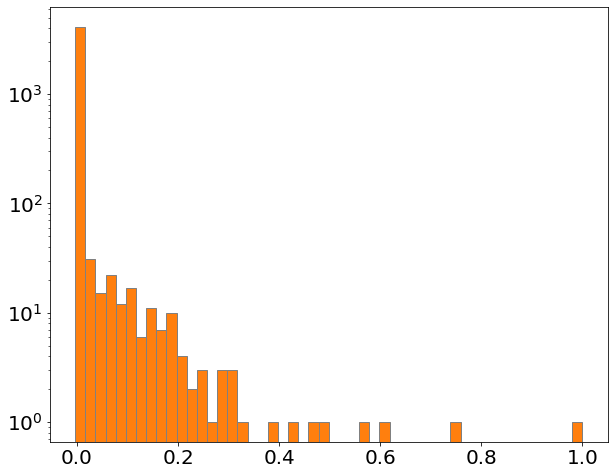

In [51]:
plt.figure(figsize=(10,8))
plt.hist(eig_norm /np.max(eig_norm ), 50, facecolor='tab:orange', ec = 'grey')
plt.yscale('log')
plt.show()

Loss Vs number of spectral lines used as input of the model

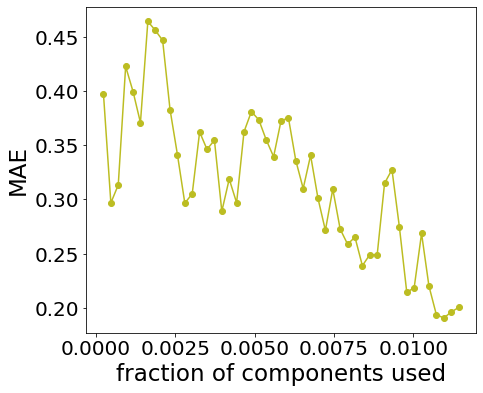

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_prune = []
mse_prune = []



max_features = 50 

for n in range(1,max_features):
    mask = eig_norm.copy()
    th = np.sort(np.abs(eig_norm))[-n]
    mask[np.abs(mask)<th]=0
    mask[np.abs(mask)>=th]=1
    y_pred = mod.predict(x_test*mask, verbose=0)
    
    mae_prune.append(mean_absolute_error(y_test, y_pred))
    mse_prune.append(mean_squared_error(y_test, y_pred)) 

xM = 200
vl = 31
plt.figure(figsize=(7,6))
plt.plot(np.arange(1, max_features)[:xM]/len(eig_norm), mae_prune[:xM], color='tab:olive',marker='o')
plt.xlabel('fraction of components used', fontsize=23)
plt.ylabel('MAE', fontsize=23)
plt.show()


An example of stellar spectra comparaed with the network eigenvalues

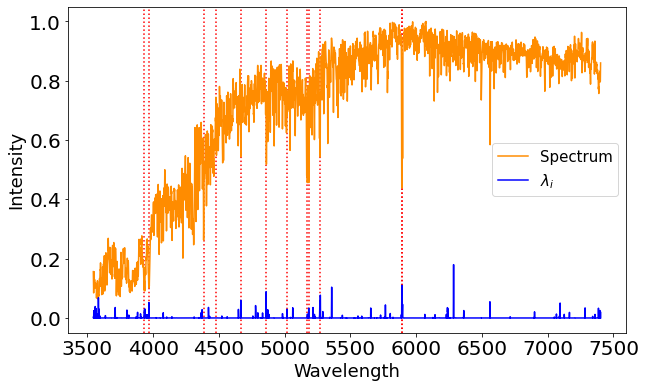

In [55]:
star_id = 's0982'
star_spectrum = df_spectrum[star_id].astype(float)

plt.figure(figsize=(10,6))

plt.axvline(3934, ls ='dotted', color = 'r')  # CaII H
plt.axvline(3968, ls ='dotted', color = 'r')  # K
plt.axvline(5173, ls ='dotted', color = 'r')  # Mg_1
plt.axvline(5184, ls ='dotted', color = 'r')  # Mg_2
plt.axvline(5270, ls ='dotted', color = 'r')  # Fe_1
plt.axvline(5896, ls ='dotted', color = 'r')  # Na_D_1
plt.axvline(5890, ls ='dotted', color = 'r')  # Na_D_2
plt.axvline(4667, ls ='dotted', color = 'r')  # FeIII(?)
plt.axvline(5018, ls ='dotted', color = 'r')  # FeII(?)
plt.axvline(4384, ls ='dotted', color = 'r')  # FeI
plt.axvline(4481, ls ='dotted', color = 'r')  # MaII(?)
plt.axvline(4861, ls ='dotted', color = 'r')  # Balmer_7

plt.plot(wavelength, star_spectrum, 'darkorange', label = 'Spectrum')
plt.plot(wavelength, np.abs(eig_norm), 'b', label = '$\lambda_i$')
plt.legend(fontsize = 15)
plt.xlabel('Wavelength', fontsize='18')
plt.ylabel('Intensity', fontsize='18')
plt.show()